In [2]:
#Install all the packages

!pip install wget
!pip install cblind

  Preparing metadata (setup.py) ... done
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9686 sha256=ad292fe950f67764198553099b6170b18807b8cc054a1274f2386db7fc92ef98
  Stored in directory: /root/.cache/pip/wheels/8a/b8/04/0c88fb22489b0c049bee4e977c5689c7fe597d6c4b0e7d0b6a
Successfully built wget


In [6]:
# Importing all the required packages
import numpy as np
import matplotlib.pyplot as plt
import pickle
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier

from tqdm import tqdm
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
from datetime import datetime, timedelta
import pandas as pd
import wget

import cblind as cb

In [30]:
fold1=pd.read_csv('Fold_1.csv')
fold2=pd.read_csv('Fold_2.csv')
fold3=pd.read_csv('Fold_3.csv')

with open('Best_Model_Inputs.pkl','rb') as f:
  All_inputs=pickle.load(f)

All_Model_Labels=['L3X60','L3X70','L3X80','L3X90','L3X95',
                  'L4X60','L4X70','L4X80','L4X90','L4X95',
                  'L5X60','L5X70','L5X80','L5X90','L5X95',
                  'GEOX60','GEOX70','GEOX80','GEOX90','GEOX95',
                  ]

All_Median_Performances={}
All_Min_Performances={}
All_Max_Performances={}

for i in range(0,len(All_Model_Labels)):
  All_Median_Performances[All_Model_Labels[i]]=[]
  All_Min_Performances[All_Model_Labels[i]]=[]
  All_Max_Performances[All_Model_Labels[i]]=[]


In [31]:
for model in tqdm(range(0,len(All_Model_Labels))):
  for leadtime in range(0,7):
      bal_acc_list=[]
      for f in range(0,3):
          folds=[]


          for fd in range(1,4):
              folds.append((pd.read_csv('Fold_'+str(fd)+'.csv')))

          test_data=folds[f]

          folds.pop(f)
          train_data=pd.concat((folds),axis=0).sample(frac=1)


          train_x=(train_data[All_inputs[All_Model_Labels[model]][leadtime]])
          train_y=(train_data[All_Model_Labels[model]+'_Class'])

          test_x=(test_data[All_inputs[All_Model_Labels[model]][leadtime]])
          test_y=(test_data[All_Model_Labels[model]+'_Class'])
          test_y=pd.to_numeric(test_y, errors='coerce')

          forest=RandomForestClassifier(n_estimators=50,max_depth=8,min_samples_leaf=100,class_weight='balanced',bootstrap=False,max_features=None,random_state=5,criterion='gini').fit(train_x,train_y)
          prediction=forest.predict(test_x)
          cm=confusion_matrix(test_y,prediction,normalize='true')


          bal_acc_list.append(balanced_accuracy_score(test_y,prediction))


      All_Median_Performances[All_Model_Labels[model]].append(np.nanmedian(bal_acc_list))
      All_Min_Performances[All_Model_Labels[model]].append(np.nanmin(bal_acc_list))
      All_Max_Performances[All_Model_Labels[model]].append(np.nanmax(bal_acc_list))

100%|██████████| 20/20 [03:28<00:00, 10.45s/it]


In [51]:
def MakePlot(Lshell):
  model_suffix=['X60','X70','X80','X90','X95']
  cmap=cb.cbmap('cb.huescale',8)
  colours=[cmap(3),cmap(4),cmap(5),cmap(6),cmap(7)]
  leadtimes=[0,1,2,3,4,5,6]
  fig,axs=plt.subplots(nrows=5,ncols=1,figsize=(7.5,15))
  plt.subplots_adjust(hspace=0.85)
  for i in range(0,5):
    axs[i].plot(leadtimes,All_Median_Performances[Lshell+model_suffix[i]],label='Median',marker='o',color=colours[i])
    axs[i].fill_between(leadtimes,All_Min_Performances[Lshell+model_suffix[i]],All_Max_Performances[Lshell+model_suffix[i]],label='Range',alpha=0.5,color=colours[i])
    axs[i].set_title('VAMPIRE-'+Lshell+model_suffix[i])
    axs[i].set_ylim(0,1)
    axs[i].set_xlabel('Lead Time (Days)')
    axs[i].set_ylabel('Balanced Accuracy')
    axs[i].legend()
    axs[i].grid()
    if Lshell=='L3':
      fig.suptitle(r'Balanced Accuracy For Each $3\leq L < 4$ VAMPIRE Model',y=0.93)
    if Lshell=='L4':
      fig.suptitle(r'Balanced Accuracy For Each $4\leq L < 5$ VAMPIRE Model',y=0.93)
    if Lshell=='L5':
      fig.suptitle(r'Balanced Accuracy For Each $5\leq L < 6$ VAMPIRE Model',y=0.93)
    if Lshell=='GEO':
      fig.suptitle(r'Balanced Accuracy For Each GEO VAMPIRE Model',y=0.93)



/tmp/ipykernel_6023/1890099584.py:3: DeprecationWarning: cblind.cbmap is deprecated. Please use matplotlib.colormaps.get_cmap instead, or matplotlib.pyplot.get_cmap if you need to specify nbin (default is 256)
  cmap=cb.cbmap('cb.huescale',8)


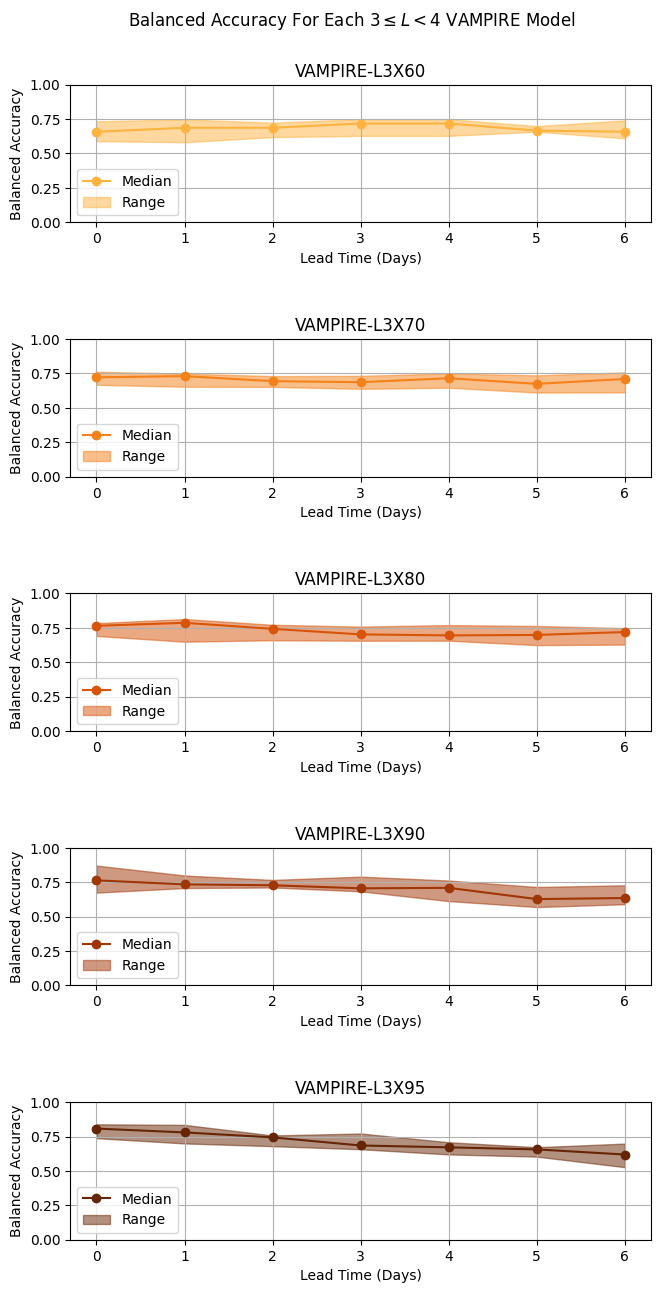

In [52]:
MakePlot('L3')

/tmp/ipykernel_6023/1890099584.py:3: DeprecationWarning: cblind.cbmap is deprecated. Please use matplotlib.colormaps.get_cmap instead, or matplotlib.pyplot.get_cmap if you need to specify nbin (default is 256)
  cmap=cb.cbmap('cb.huescale',8)


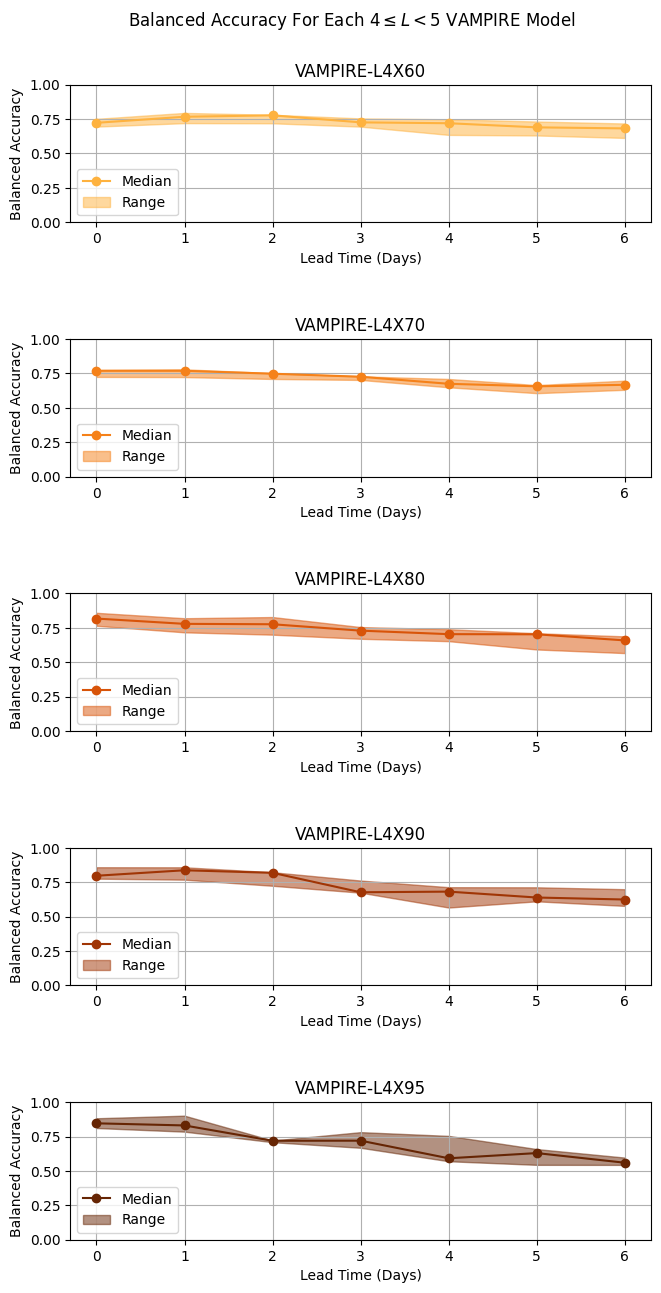

In [53]:
MakePlot('L4')

/tmp/ipykernel_6023/1890099584.py:3: DeprecationWarning: cblind.cbmap is deprecated. Please use matplotlib.colormaps.get_cmap instead, or matplotlib.pyplot.get_cmap if you need to specify nbin (default is 256)
  cmap=cb.cbmap('cb.huescale',8)


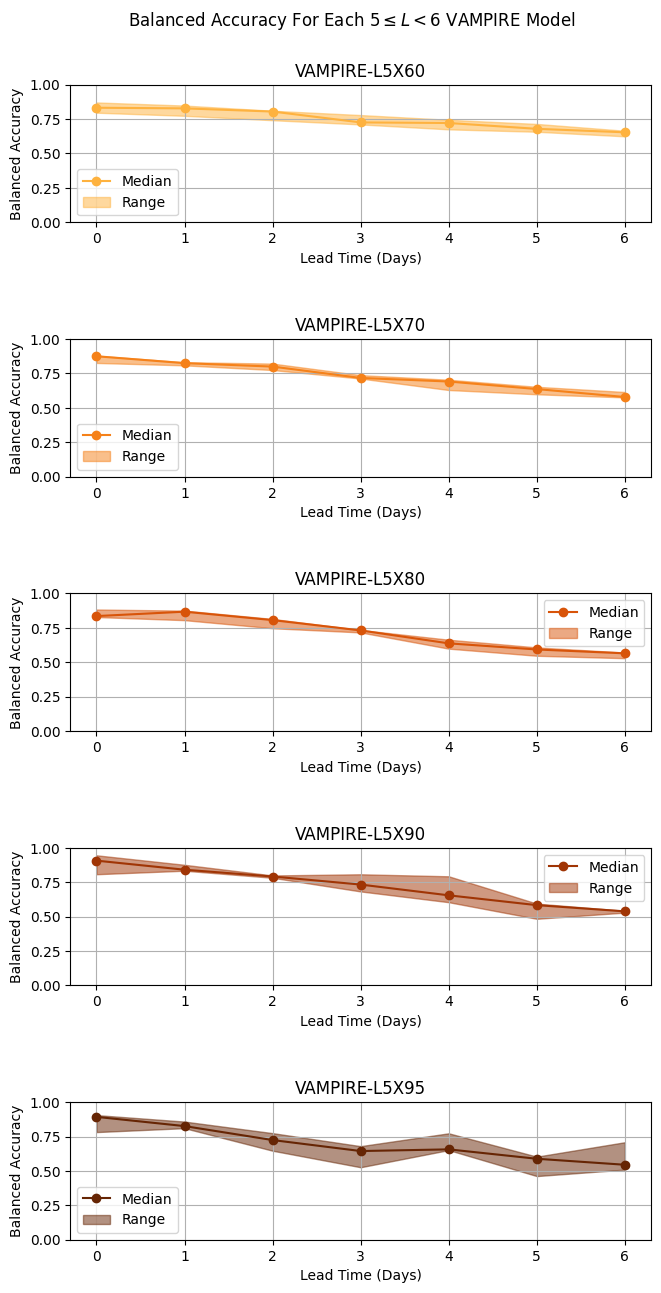

In [54]:
MakePlot('L5')

/tmp/ipykernel_6023/1890099584.py:3: DeprecationWarning: cblind.cbmap is deprecated. Please use matplotlib.colormaps.get_cmap instead, or matplotlib.pyplot.get_cmap if you need to specify nbin (default is 256)
  cmap=cb.cbmap('cb.huescale',8)


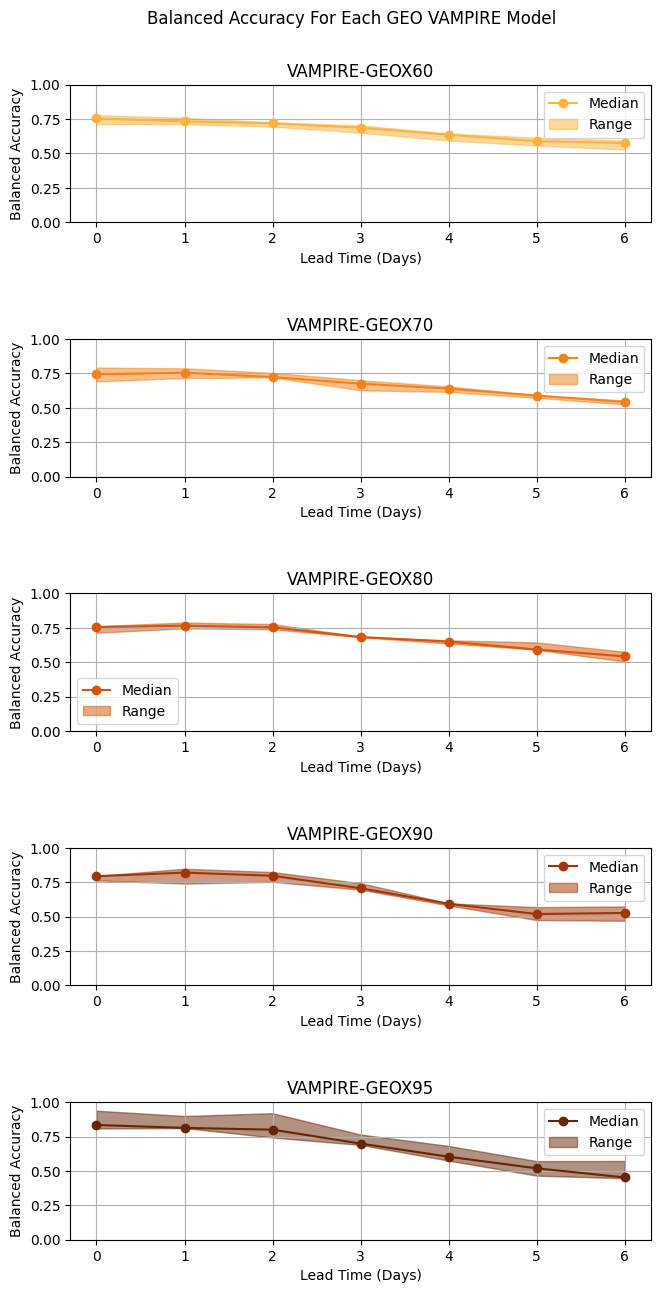

In [55]:
MakePlot('GEO')